# Weekend Dataset EDA\n
\n
Reads `structured_csv_data_files/Weekend_dataset.csv` (Monday + Friday rows only) and visualizes distributions + a simple weekend-gap calculation.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
REPO_ROOT = Path.cwd().resolve().parent.parent  # notebooks/EDA -> repo root 
WEEKEND_CSV = REPO_ROOT / "structured_csv_data_files" / "Weekend_dataset.csv"
WEEKEND_CSV

PosixPath('/Users/shaunaksoni/Cursor/ML Project/ml-weekend-gap-prediction/structured_csv_data_files/Weekend_dataset.csv')

In [2]:
w = pd.read_csv(WEEKEND_CSV)
w.shape

(24894, 39)

In [3]:
w.head(10)

,Year,Quarter,Date,Ticker,Open,Close,High,Low,Volume,Revenues,...,BollingerBandWidth,ATR,FiveDStdDev,OBV,MFI,VolumeRatio,GrossMargin,NetMargin,RoA,RevGrowthQoQ
0,2016,Q1,2016-03-28 00:00:00-04:00,CRM,71.521001,71.086281,71.807521,70.552770,2688100,1.916603e+09,...,NaN,NaN,NaN,0,NaN,1.089821,0.741,0.020,0.003,NaN
1,2016,Q2,2016-04-01 00:00:00-04:00,CRM,72.499112,74.820908,75.038260,72.232356,4550600,2.036618e+09,...,NaN,1.869287,NaN,10110900,52.955228,1.089821,0.742,0.113,0.016,NaN
2,2016,Q2,2016-04-04 00:00:00-04:00,CRM,74.939463,74.781387,75.522384,74.504750,2978100,2.036618e+09,...,NaN,1.821864,0.015515,7132800,59.623733,0.846914,0.742,0.113,0.016,0.0
3,2016,Q2,2016-04-08 00:00:00-04:00,CRM,74.811028,73.951469,75.028389,73.408076,2375700,2.036618e+09,...,NaN,1.207329,0.010242,581300,37.036823,0.846914,0.742,0.113,0.016,0.0
4,2016,Q2,2016-04-11 00:00:00-04:00,CRM,74.564024,73.269753,74.593663,73.240106,2151800,2.036618e+09,...,NaN,1.274513,0.010599,-1570500,15.976696,0.835809,0.742,0.113,0.016,0.0
5,2016,Q2,2016-04-15 00:00:00-04:00,CRM,75.334666,75.393944,75.621186,74.969105,2132900,2.036618e+09,...,NaN,1.181641,0.011546,8618200,64.737495,0.835809,0.742,0.113,0.016,0.0
6,2016,Q2,2016-04-18 00:00:00-04:00,CRM,75.324781,76.342415,76.362179,74.949345,1916100,2.036618e+09,...,NaN,1.193496,0.009225,10534300,81.736204,1.296436,0.742,0.113,0.016,0.0
7,2016,Q2,2016-04-22 00:00:00-04:00,CRM,75.314898,75.561897,75.947215,74.445458,3184500,2.036618e+09,...,0.076273,1.545227,0.012290,6525500,42.195177,1.296436,0.742,0.113,0.016,0.0
8,2016,Q2,2016-04-25 00:00:00-04:00,CRM,75.265497,75.591537,75.907696,74.969095,2456200,2.036618e+09,...,0.065620,1.450380,0.010352,8981700,44.452672,1.113679,0.742,0.113,0.016,0.0
9,2016,Q2,2016-04-29 00:00:00-04:00,CRM,74.109558,74.890076,75.146949,73.585922,3228000,2.036618e+09,...,0.044797,1.308104,0.004852,3071900,42.463535,1.113679,0.742,0.113,0.016,0.0


In [4]:
# Parse dates + weekday labels 
w["Date_parsed"] = pd.to_datetime(w["Date"], errors="coerce", utc=True)
w["weekday"] = w["Date_parsed"].dt.day_name()
w["weekday"].value_counts()

weekday
Friday    12945
Monday    11949
Name: count, dtype: int64

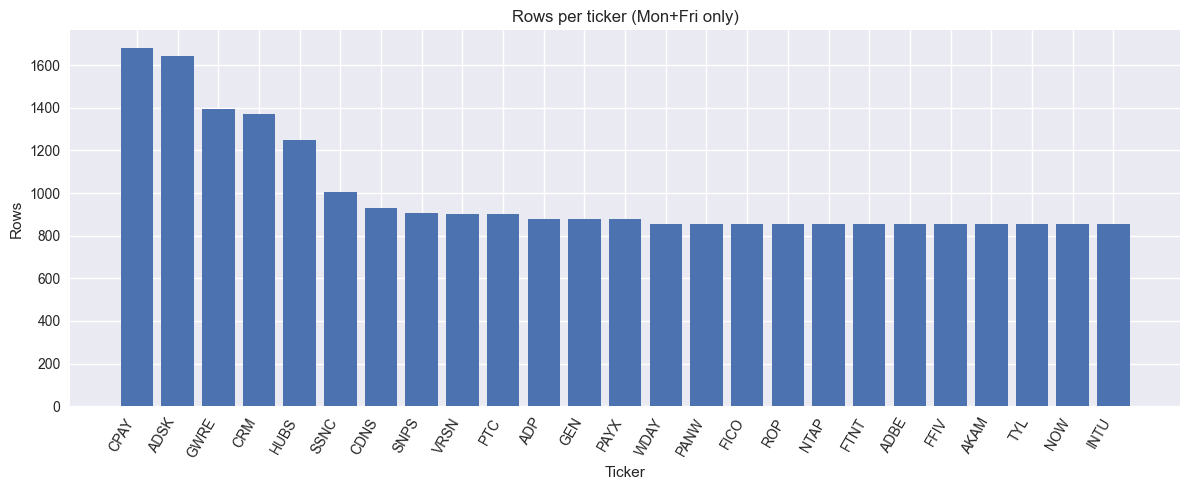

In [5]:
# Rows per ticker 
if "Ticker" in w.columns:
    vc = w["Ticker"].value_counts().sort_values(ascending=False)
    plt.bar(vc.index.astype(str), vc.values)
    plt.title("Rows per ticker (Mon+Fri only)")
    plt.xlabel("Ticker")
    plt.ylabel("Rows")
    plt.xticks(rotation=60, ha="right")
    plt.tight_layout()
    plt.show()

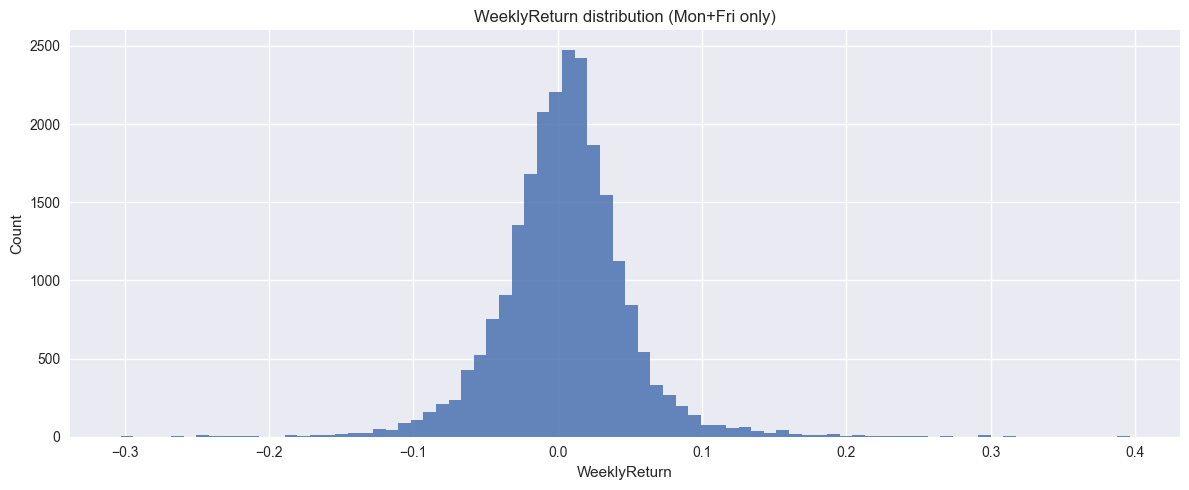

In [6]:
# WeeklyReturn distribution (if available) 
if "WeeklyReturn" in w.columns:
    s = pd.to_numeric(w["WeeklyReturn"], errors="coerce").dropna()
    plt.hist(s, bins=80, alpha=0.85) 
    plt.title("WeeklyReturn distribution (Mon+Fri only)") 
    plt.xlabel("WeeklyReturn") 
    plt.ylabel("Count") 
    plt.tight_layout() 
    plt.show()

,Ticker,Date_parsed,Open_num,prev_friday_close,gap_pct
3942,ADBE,2016-04-04 04:00:00+00:00,95.419998,95.160004,0.002732
3944,ADBE,2016-04-11 04:00:00+00:00,94.430000,94.070000,0.003827
3946,ADBE,2016-04-18 04:00:00+00:00,94.750000,95.160004,-0.004309
3948,ADBE,2016-04-25 04:00:00+00:00,94.379997,94.790001,-0.004325
3950,ADBE,2016-05-02 04:00:00+00:00,94.290001,94.220001,0.000743
3952,ADBE,2016-05-09 04:00:00+00:00,94.000000,94.300003,-0.003181
3954,ADBE,2016-05-16 04:00:00+00:00,95.910004,95.970001,-0.000625
3956,ADBE,2016-05-23 04:00:00+00:00,96.709999,96.879997,-0.001755
3959,ADBE,2016-06-06 04:00:00+00:00,99.160004,98.699997,0.004661
3961,ADBE,2016-06-13 04:00:00+00:00,96.870003,97.089996,-0.002266


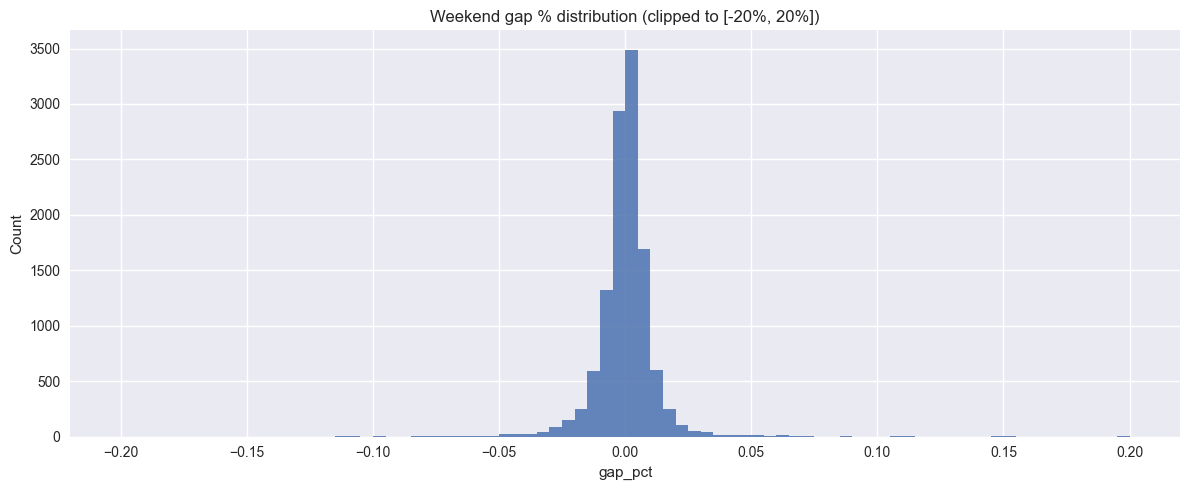

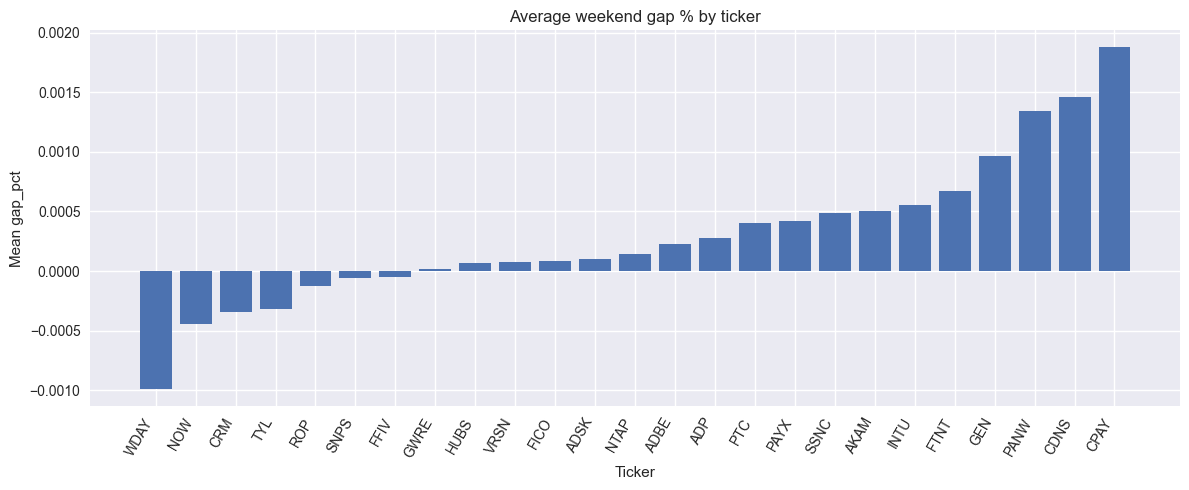

In [7]:
# Weekend gap calculation per ticker: Monday Open vs previous Friday Close 
# gap_pct = (MonOpen - FriClose) / FriClose 
needed = {"Ticker", "Date_parsed", "Open", "Close"} 
if needed.issubset(w.columns): 
    tmp = w.copy() 
    tmp["Open_num"] = pd.to_numeric(tmp["Open"], errors="coerce") 
    tmp["Close_num"] = pd.to_numeric(tmp["Close"], errors="coerce") 
    tmp = tmp.dropna(subset=["Ticker", "Date_parsed", "Open_num", "Close_num"]).sort_values(["Ticker", "Date_parsed"]) 
 
    # Identify Fridays and shift their Close forward to match the next row (often Monday) 
    tmp["is_friday"] = tmp["Date_parsed"].dt.weekday == 4 
    tmp["prev_close_if_friday"] = tmp["Close_num"].where(tmp["is_friday"]) 
    tmp["prev_friday_close"] = tmp.groupby("Ticker")["prev_close_if_friday"].ffill() 
 
    # Keep only Mondays with a previous Friday close 
    mondays = tmp.loc[tmp["Date_parsed"].dt.weekday == 0].copy() 
    mondays = mondays.dropna(subset=["prev_friday_close"]) 
    mondays["gap_pct"] = (mondays["Open_num"] - mondays["prev_friday_close"]) / mondays["prev_friday_close"] 
 
    display(mondays[["Ticker", "Date_parsed", "Open_num", "prev_friday_close", "gap_pct"]].head(10)) 
    plt.hist(mondays["gap_pct"].clip(-0.2, 0.2), bins=80, alpha=0.85) 
    plt.title("Weekend gap % distribution (clipped to [-20%, 20%])") 
    plt.xlabel("gap_pct") 
    plt.ylabel("Count") 
    plt.tight_layout() 
    plt.show() 
 
    # Average gap per ticker 
    g = mondays.groupby("Ticker")["gap_pct"].mean().sort_values() 
    plt.bar(g.index.astype(str), g.values) 
    plt.title("Average weekend gap % by ticker") 
    plt.xlabel("Ticker") 
    plt.ylabel("Mean gap_pct") 
    plt.xticks(rotation=60, ha="right") 
    plt.tight_layout() 
    plt.show()

## Modeling table (Friday  next Monday)

To predict **Monday Open**, we should build samples where:
- **Features** come from the **Friday row** (known before the weekend)
- **Target** comes from the **next Monday row**

This avoids leaking Monday information into training.

We’ll also define alternative targets:
- **Regression**: `y_open_mon` (raw Monday open) or `y_gap_pct` (weekend gap %)
- **Classification (for Logistic Regression)**: `y_gap_up = 1 if y_gap_pct > 0 else 0`

In [ ]:
# Build a paired dataset: each row = Friday features + next Monday targets
import numpy as np

w2 = w.copy()
w2["Date_parsed"] = pd.to_datetime(w2["Date"], errors="coerce", utc=True)
w2["weekday_num"] = w2["Date_parsed"].dt.weekday  # Mon=0 ... Sun=6

# Numeric conversions for price columns we care about
for c in ["Open", "Close", "High", "Low", "Volume"]:
    if c in w2.columns:
        w2[c] = pd.to_numeric(w2[c], errors="coerce")

w2 = w2.dropna(subset=["Ticker", "Date_parsed"]).sort_values(["Ticker", "Date_parsed"]).reset_index(drop=True)

# Next-row join within each ticker (weekend dataset is only Mon/Fri, but we still guard for gaps)
w2["next_weekday"] = w2.groupby("Ticker")["weekday_num"].shift(-1)
w2["next_date"] = w2.groupby("Ticker")["Date_parsed"].shift(-1)
w2["next_open"] = w2.groupby("Ticker")["Open"].shift(-1)
w2["next_close"] = w2.groupby("Ticker")["Close"].shift(-1)

pairs = w2.loc[(w2["weekday_num"] == 4) & (w2["next_weekday"] == 0)].copy()  # Friday -> Monday

# Keep only plausible weekend transitions (Fri->Mon should be ~3 days; allow holiday weekends too)
delta_days = (pairs["next_date"] - pairs["Date_parsed"]).dt.days
pairs = pairs.loc[(delta_days >= 3) & (delta_days <= 5)].copy()

pairs["y_open_mon"] = pairs["next_open"]
pairs["y_gap_pct"] = (pairs["next_open"] - pairs["Close"]) / pairs["Close"]
pairs["y_gap_up"] = (pairs["y_gap_pct"] > 0).astype(int)

pairs[["Ticker", "Date_parsed", "next_date", "Close", "next_open", "y_gap_pct", "y_gap_up"]].head()

In [ ]:
pairs.shape, pairs["Ticker"].nunique(), pairs["Date_parsed"].min(), pairs["next_date"].max()

In [ ]:
# Target sanity: distributions
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

ax[0].hist(pairs["y_gap_pct"].dropna().clip(-0.2, 0.2), bins=80, alpha=0.85)
ax[0].set_title("Weekend gap % (clipped [-20%, 20%])")
ax[0].set_xlabel("y_gap_pct")
ax[0].set_ylabel("Count")

ax[1].bar(["down/flat", "up"], [int((pairs["y_gap_up"] == 0).sum()), int((pairs["y_gap_up"] == 1).sum())])
ax[1].set_title("Gap direction class balance")
ax[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [ ]:
# Feature audit: missingness on Friday features (top 25)
# NOTE: we only use Friday-row columns as candidate features.
exclude = {
    "Date",
    "Date_parsed",
    "weekday_num",
    "next_weekday",
    "next_date",
    "next_open",
    "next_close",
    "y_open_mon",
    "y_gap_pct",
    "y_gap_up",
}

feature_cols = [c for c in pairs.columns if c not in exclude]

missing = pairs[feature_cols].isna().mean().sort_values(ascending=False)
missing.head(25)

In [ ]:
# Correlation with target (quick signal scan)
num_features = [c for c in feature_cols if pd.api.types.is_numeric_dtype(pairs[c])]

corr = pairs[num_features + ["y_gap_pct"]].corr(numeric_only=True)["y_gap_pct"].sort_values(key=lambda s: s.abs(), ascending=False)
corr.head(25)

In [ ]:
# Time coverage + sample counts over time
pairs["monday_date"] = pairs["next_date"]

counts_by_year = pairs["monday_date"].dt.year.value_counts().sort_index()
plt.figure(figsize=(10, 3))
plt.bar(counts_by_year.index.astype(int), counts_by_year.values)
plt.title("Paired samples by Monday year")
plt.xlabel("Year")
plt.ylabel("# samples")
plt.tight_layout()
plt.show()